In [19]:
from nba_api.stats.endpoints import leaguedashptstats

# Requesting league-wide player tracking camera metrics
logs = leaguedashptstats.LeagueDashPtStats(
    season="2024-25",
    season_type_all_star="Regular Season",
    player_or_team="Player",     # Forces individual player telemetry instead of team metrics
    pt_measure_type="Rebounding" # Unlocks REB_CHANCES, REB_CHANCE_PCT, etc.
    , per_mode_simple="PerGame"
)

tracking_df = logs.get_data_frames()[0]

print(tracking_df.columns.tolist())

['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'GP', 'W', 'L', 'MIN', 'OREB', 'OREB_CONTEST', 'OREB_UNCONTEST', 'OREB_CONTEST_PCT', 'OREB_CHANCES', 'OREB_CHANCE_PCT', 'OREB_CHANCE_DEFER', 'OREB_CHANCE_PCT_ADJ', 'AVG_OREB_DIST', 'DREB', 'DREB_CONTEST', 'DREB_UNCONTEST', 'DREB_CONTEST_PCT', 'DREB_CHANCES', 'DREB_CHANCE_PCT', 'DREB_CHANCE_DEFER', 'DREB_CHANCE_PCT_ADJ', 'AVG_DREB_DIST', 'REB', 'REB_CONTEST', 'REB_UNCONTEST', 'REB_CONTEST_PCT', 'REB_CHANCES', 'REB_CHANCE_PCT', 'REB_CHANCE_DEFER', 'REB_CHANCE_PCT_ADJ', 'AVG_REB_DIST']


Base Shape: (564, 35)
Final Joined Shape: (564, 35)
Missing Values:
 REB_CHANCES    0
REB            0
dtype: int64


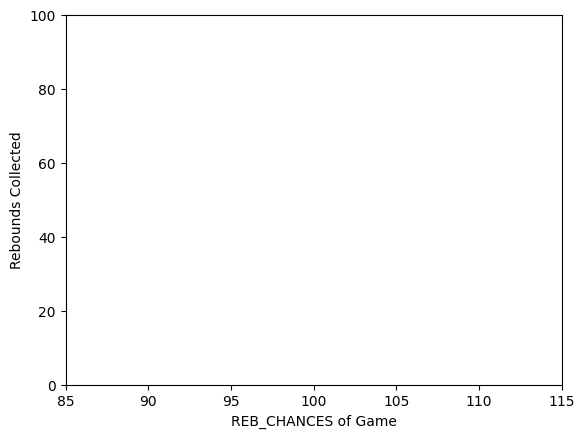

Correlation: 0.973953588669787
R2 Score: 0.9485855928827569


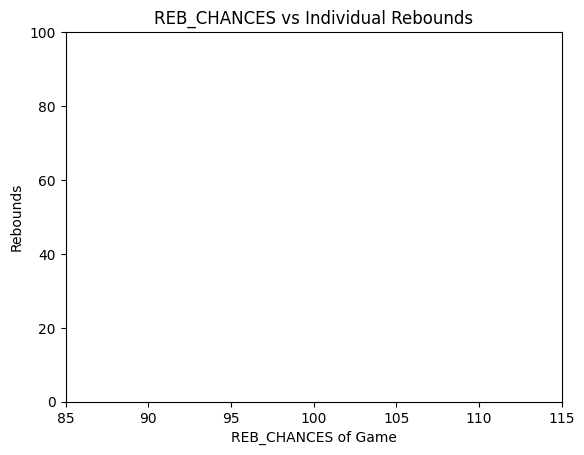

In [ ]:
# Create your clean analytics sandbox slice
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
chances_reb = tracking_df[["REB_CHANCES", "REB"]]
print("Base Shape:", tracking_df.shape)
print("Final Joined Shape:", tracking_df.shape)
print("Missing Values:\n", chances_reb.isnull().sum())

plt.scatter(chances_reb["REB_CHANCES"], chances_reb["REB"])
plt.xlim(85, 115) # Adjusted boundaries to match real team-wide miss distributions
plt.ylim(0, 100)
plt.xlabel("REB_CHANCES of Game")
plt.ylabel("Rebounds Collected")
plt.show()

print("Correlation:", chances_reb["REB_CHANCES"].corr(chances_reb["REB"]))

# 5. Initialize, Fit, and Execute your Machine Learning Regression
X = chances_reb[["REB_CHANCES"]]
y = chances_reb["REB"]

model = LinearRegression()
model.fit(X, y) # Fit the brain first!
r2 = model.score(X, y)
print("R2 Score:", r2)

# 6. Sort your feature matrix sequentially to draw a crisp trend line
X_sorted = X.sort_values("REB_CHANCES")
predictions_sorted = model.predict(X_sorted)

# 7. Generate your final diagnostic report visualization
plt.scatter(chances_reb["REB_CHANCES"], chances_reb["REB"])
plt.plot(X_sorted["REB_CHANCES"], predictions_sorted, color="red") 

plt.xlim(85, 115)
plt.ylim(0, 100)
plt.xlabel("REB_CHANCES of Game")
plt.ylabel("Rebounds")
plt.title("REB_CHANCES vs Individual Rebounds")
plt.show()
